Saving archive (2).zip to archive (2) (2).zip
Loaded file: archive (2) (2).zip
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...     

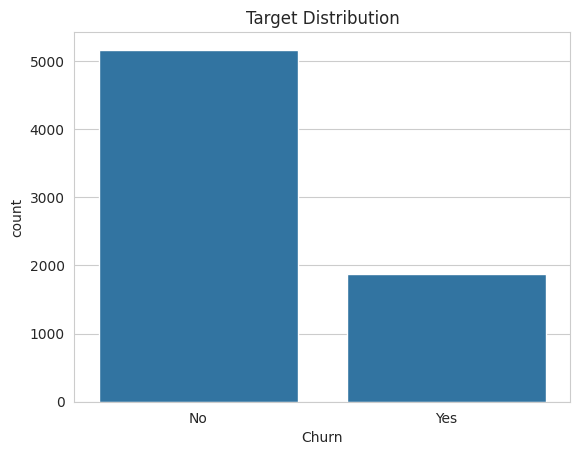

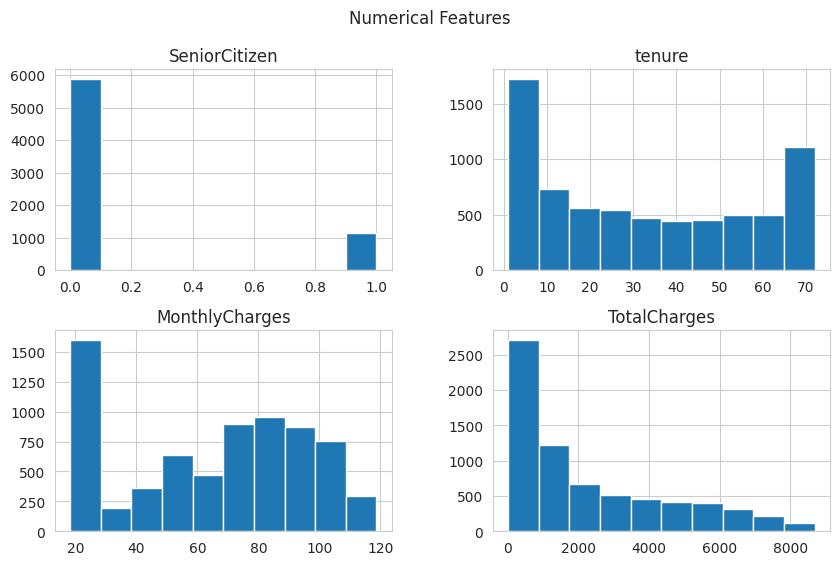

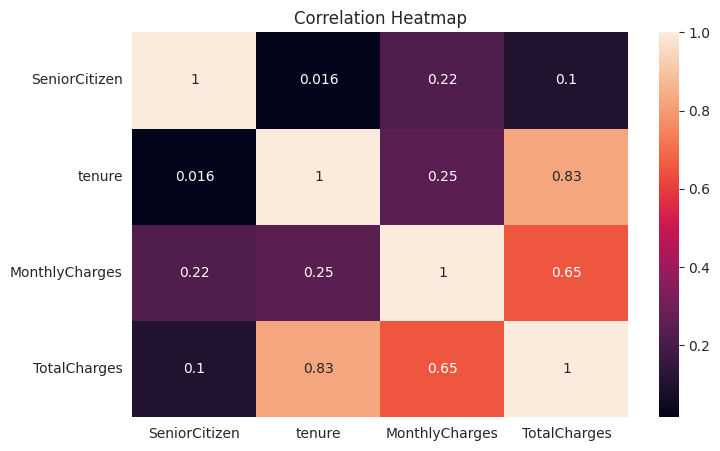


Model Results:
                      Accuracy  Precision    Recall  F1 Score
Logistic Regression  0.785359   0.620805  0.494652  0.550595
Decision Tree        0.727079   0.487047  0.502674  0.494737
Random Forest        0.787491   0.633452  0.475936  0.543511


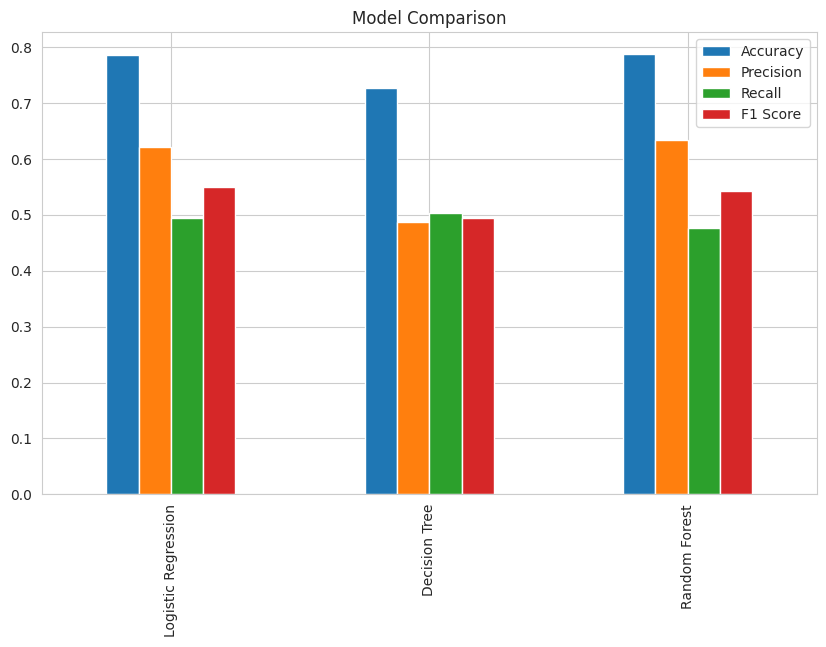

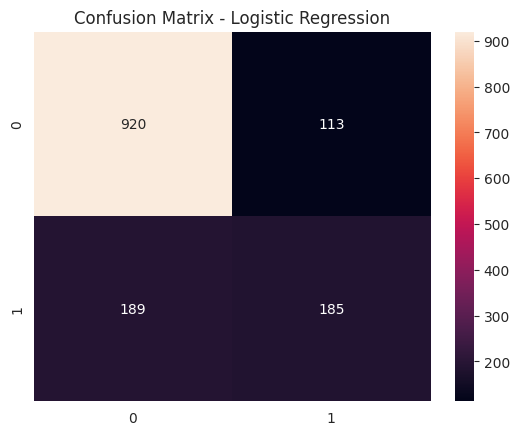

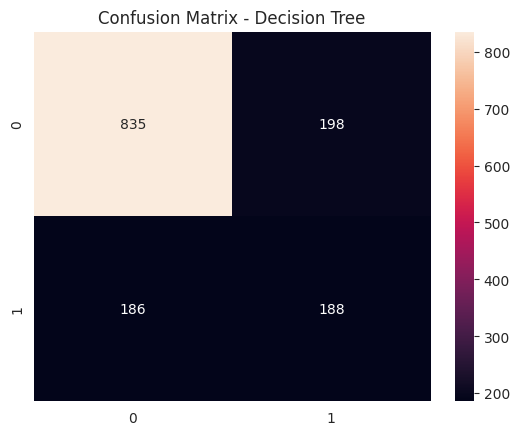

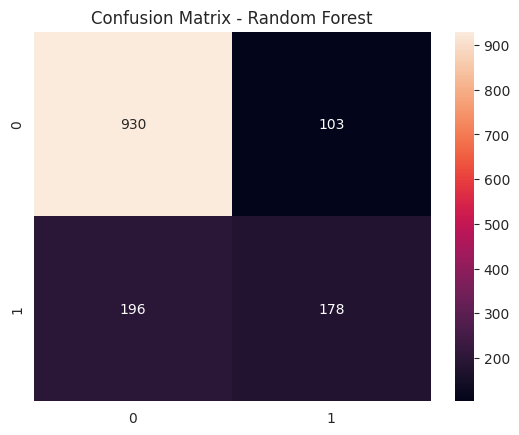

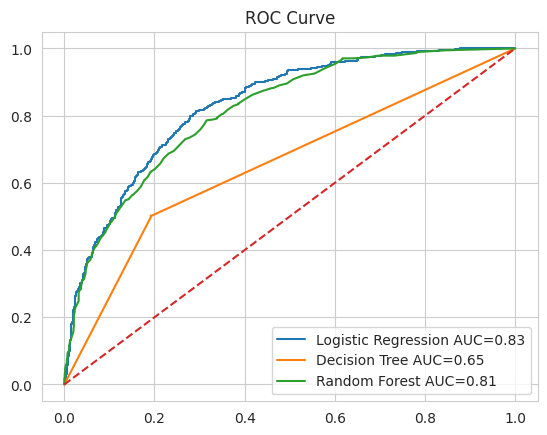

Best Params: {'max_depth': 10, 'n_estimators': 50}


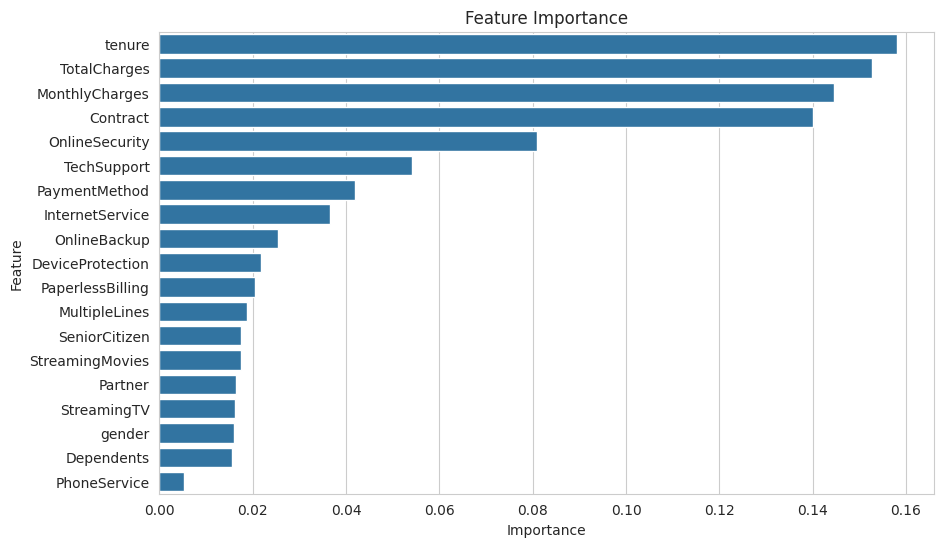

In [3]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

sns.set_style("whitegrid")


# ==============================
# 2. UPLOAD DATASET (FIXED)
# ==============================
from google.colab import files

uploaded = files.upload()

# Get the uploaded file name automatically
file_name = list(uploaded.keys())[0]
print("Loaded file:", file_name)

df = pd.read_csv(file_name)


# ==============================
# 3. BASIC CHECK
# ==============================
print(df.head())
print(df.columns)


# ==============================
# 4. DATA CLEANING
# ==============================

# Fix TotalCharges issue (common in this dataset)
if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df.dropna(inplace=True)

# Drop ID column if exists
if "customerID" in df.columns:
    df.drop("customerID", axis=1, inplace=True)


# ==============================
# 5. EDA
# ==============================

# Target column check
target_col = "Churn" if "Churn" in df.columns else df.columns[-1]

plt.figure()
sns.countplot(x=target_col, data=df)
plt.title("Target Distribution")
plt.show()

# Numerical columns
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(figsize=(10,6))
plt.suptitle("Numerical Features")
plt.show()

# Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df[num_cols].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()


# ==============================
# 6. PREPROCESSING
# ==============================

# Encode categorical
le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

# Split
X = df.drop(target_col, axis=1)
y = df[target_col]

# Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ==============================
# 7. TRAIN MODELS
# ==============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    trained_models[name] = model

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    }

results_df = pd.DataFrame(results).T
print("\nModel Results:\n", results_df)


# ==============================
# 8. MODEL COMPARISON
# ==============================
results_df.plot(kind="bar", figsize=(10,6))
plt.title("Model Comparison")
plt.show()


# ==============================
# 9. CONFUSION MATRIX
# ==============================
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()


# ==============================
# 10. ROC CURVE
# ==============================
plt.figure()

for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} AUC={roc_auc:.2f}")

plt.plot([0,1], [0,1], linestyle="--")
plt.legend()
plt.title("ROC Curve")
plt.show()


# ==============================
# 11. HYPERPARAMETER TUNING
# ==============================
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [None, 10]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Params:", grid.best_params_)


# ==============================
# 12. FEATURE IMPORTANCE
# ==============================
importances = best_model.feature_importances_
feature_names = df.drop(target_col, axis=1).columns

feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_df)
plt.title("Feature Importance")
plt.show()